In [6]:
import pandas as pd
import os
from pathlib import Path

In [7]:
golden_location = Path(
    os.environ.get(
        "GOLDEN_LOCATION",
        Path.home() / "Documents" / "GitHub" / "data" / "Golden_Data",
    )
)
start_year = 2015 
end_year = 2024
 
lc = pd.read_csv(golden_location / "LC_dataset_v_2C_20260512.csv")

lc =  lc[lc["loc"] == "USA"]

lc = lc[(lc["rfyear"] >= start_year) & (lc["rfyear"] <= end_year)]

lc["gvkey"].nunique()



/var/folders/sk/z7ggmvz1553d4mb_3z2lyw0r0000gp/T/ipykernel_30232/2345488994.py:10: DtypeWarning: Columns (516) have mixed types. Specify dtype option on import or set low_memory=False.
  lc = pd.read_csv(golden_location / "LC_dataset_v_2C_20260512.csv")


2960

Create the Signals

In [8]:
# --- Add behavioural signals the SAME way as Main (no sample filtering) ---
# dict_2d_actions_stakeholders_original_matteo maps each action-type column to a
# stakeholder bucket: 0 = advocacy, 1 = preparation, 2 = transformation.
import sys, os
_root = os.getcwd()
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "functions")):
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

from functions.signal_design.signal_definitions import dict_2d_actions_stakeholders_original_matteo

categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_2d_actions_stakeholders_original_matteo()
signal_denominator = "Sum_All_Signals"

# 1) Sum action-type columns into each stakeholder bucket -> sum_with_{i}
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

# 2) Denominator = total activities across all mapped categories
if signal_denominator == "Sum_All_Signals":
    lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)
elif signal_denominator == "Sum_All_Initiatives":
    lc['sum_activities'] = lc['n_predicted_initiatives']

# 3) signal_i = sum_with_i / sum_activities  (share of activity in each bucket)
max_category = max(categories_dict.values())
for i in range(max_category + 1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

signal_names = {"signal_0": signal_0_name, "signal_1": signal_1_name, "signal_2": signal_2_name}
print("Signals added:", signal_names)
lc[['gvkey', 'rfyear', 'signal_0', 'signal_1', 'signal_2']].head()

/var/folders/sk/z7ggmvz1553d4mb_3z2lyw0r0000gp/T/ipykernel_30232/686751260.py:21: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  lc[f'sum_with_{value}'] = lc[key].values
/var/folders/sk/z7ggmvz1553d4mb_3z2lyw0r0000gp/T/ipykernel_30232/6867512

Signals added: {'signal_0': 'advocacy', 'signal_1': 'preparation', 'signal_2': 'transformation'}


/var/folders/sk/z7ggmvz1553d4mb_3z2lyw0r0000gp/T/ipykernel_30232/686751260.py:32: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']
/var/folders/sk/z7ggmvz1553d4mb_3z2lyw0r0000gp/T/i

,gvkey,rfyear,signal_0,signal_1,signal_2
10,4926.0,2017,0.590909,0.318182,0.090909
12,33767.0,2023,0.363636,0.424242,0.212121
14,5735.0,2020,0.586207,0.310345,0.103448
30,206243.0,2016,0.757576,0.121212,0.121212
32,12138.0,2018,0.550000,0.300000,0.150000


Merge with USA Compustat

In [9]:
# --- Merge LC with the USA Compustat universe (gvkey intersection) ---
# Mirrors `intersect_gvkeys_and_filter` in the main pipeline: keep only LC firms
# whose gvkey also exists in the USA Compustat universe (with return data).
# NOTE: raw LC `gvkey` is a float, so it must go via int BEFORE zero-padding,
# otherwise "258898.0" is compared against "258898" and nothing matches.
if "_root" not in globals():
    _root = os.getcwd()
    while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "functions")):
        _root = os.path.dirname(_root)

lc = lc.dropna(subset=["gvkey"]).copy()
lc["gvkey"] = lc["gvkey"].astype(int).astype(str).str.zfill(6)

usa_universe = pd.read_csv(
    Path(_root) / "data" / "usa_universe.csv",
    usecols=["date", "gvkey", "tri"],
    low_memory=False,
).dropna(subset=["gvkey", "tri"])
usa_universe["gvkey"] = (
    usa_universe["gvkey"].astype(float).astype(int).astype(str).str.zfill(6)
)

compustat_gvkeys = set(usa_universe["gvkey"].unique())
lc_merged = lc[lc["gvkey"].isin(compustat_gvkeys)].copy()

print(f"LC firms                : {lc['gvkey'].nunique():5d}   firm-years {len(lc):6d}")
print(f"Compustat USA firms     : {len(compustat_gvkeys):5d}")
print(f"Intersection (matched)  : {lc_merged['gvkey'].nunique():5d}   firm-years {len(lc_merged):6d}")
print(f"  -> retained {100 * lc_merged['gvkey'].nunique() / lc['gvkey'].nunique():.1f}% of LC firms")

/var/folders/sk/z7ggmvz1553d4mb_3z2lyw0r0000gp/T/ipykernel_30232/3717163940.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  lc["gvkey"] = lc["gvkey"].astype(int).astype(str).str.zfill(6)
/var/folders/sk/z7ggmvz1553d4mb_3z2lyw0r0000gp/T/

LC firms                :  2960   firm-years  11578
Compustat USA firms     :  2412
Intersection (matched)  :  1380   firm-years   7090
  -> retained 46.6% of LC firms


Analyse the Trends

[plot] saved outputs/LC_USA_No_Filter/fig1_firms_and_initiatives.png
[data] saved outputs/LC_USA_No_Filter/fig1_firms_and_initiatives.xlsx


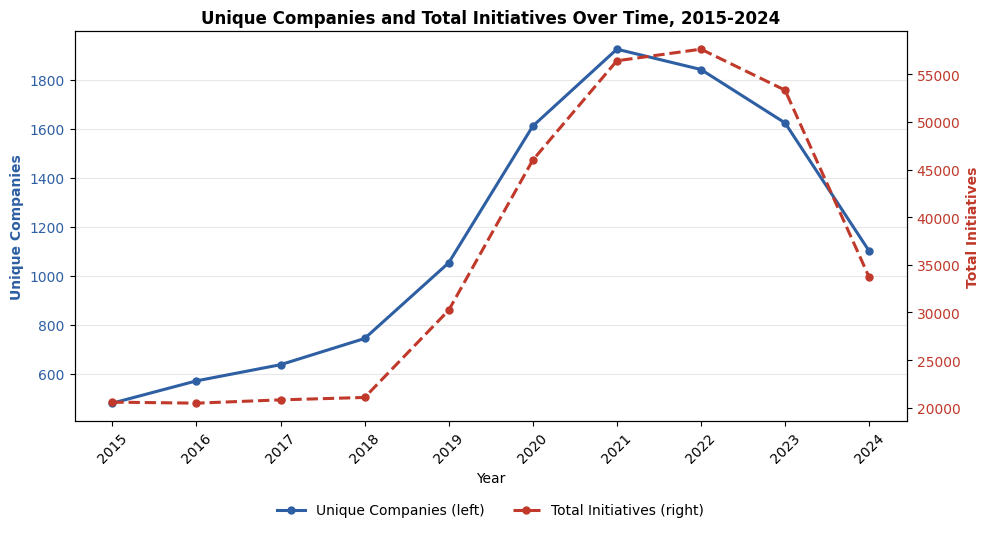

[plot] saved outputs/LC_USA_No_Filter/fig2_signal_shares_over_time.png
[data] saved outputs/LC_USA_No_Filter/fig2_signal_shares_over_time.xlsx


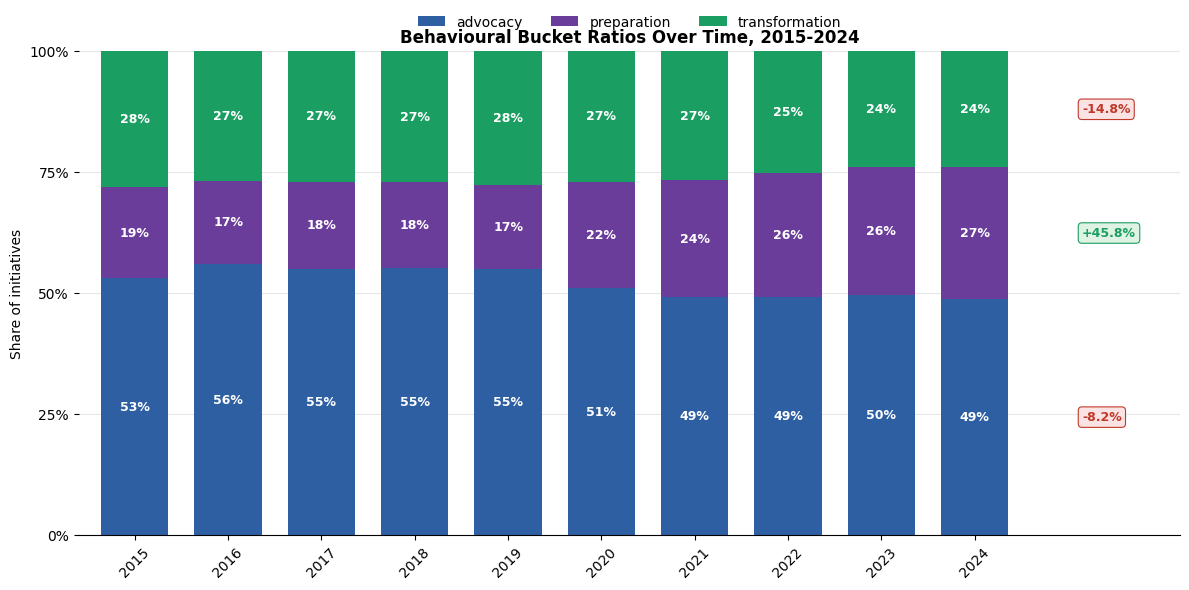

[plot] saved outputs/LC_USA_No_Filter/fig3_signal_shares_by_sector.png
[data] saved outputs/LC_USA_No_Filter/fig3_signal_shares_by_sector.xlsx


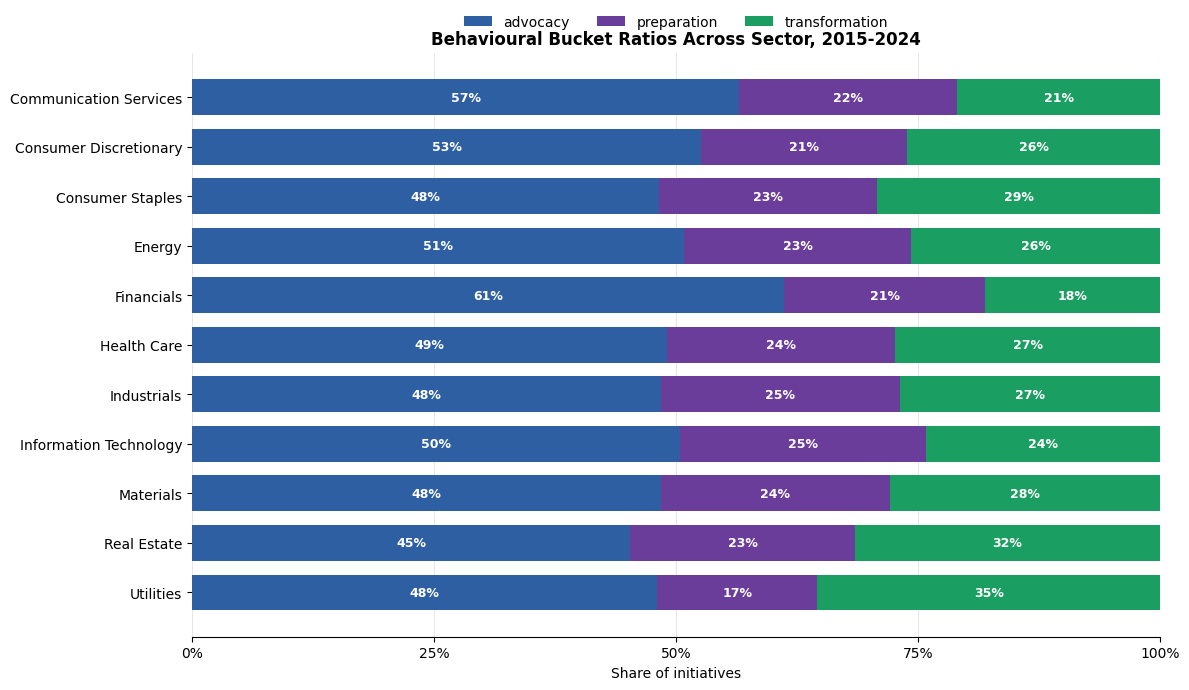

,unique_companies,firm_year_observations,total_initiatives
rfyear,,,
2015,479,479,20596
2016,570,570,20489
2017,636,636,20834
2018,743,743,21088
2019,1052,1052,30236
2020,1610,1610,45989
2021,1924,1924,56408
2022,1841,1841,57625
2023,1623,1623,53324


,advocacy,preparation,transformation
rfyear,,,
2015,53.2,18.6,28.1
2016,56.1,17.1,26.8
2017,55.1,17.9,27.0
2018,55.2,17.8,27.0
2019,54.9,17.4,27.6
2020,51.1,22.0,26.9
2021,49.2,24.2,26.6
2022,49.3,25.6,25.1
2023,49.8,26.4,23.9


,advocacy,preparation,transformation,n_obs
GICS_level_1,,,,
Utilities,48.0,16.5,35.4,638
Real Estate,45.3,23.2,31.5,771
Materials,48.5,23.6,28.0,822
Information Technology,50.4,25.3,24.2,1387
Industrials,48.4,24.7,26.9,1926
Health Care,49.1,23.6,27.4,1171
Financials,61.2,20.7,18.1,1720
Energy,50.9,23.4,25.7,709
Consumer Staples,48.3,22.5,29.2,684


In [10]:
# --- Descriptive plots (functions live in descriptive_plots.py) ---
import importlib
import descriptive_plots
importlib.reload(descriptive_plots)   # pick up edits without restarting the kernel
from descriptive_plots import (
    plot_firms_and_initiatives,
    plot_signal_shares_over_time,
    plot_signal_shares_by_sector,
)

OUT = Path("outputs") / "LC_USA_No_Filter"   # full LC sample (no filtering)
OUT.mkdir(parents=True, exist_ok=True)

# 1) Firm-year observations / unique companies + total initiatives over time
fig1, firms_initiatives = plot_firms_and_initiatives(
    lc,
    title=f"Unique Companies and Total Initiatives Over Time, {start_year}-{end_year}",
    save_path=OUT / "fig1_firms_and_initiatives.png",
    excel_path=OUT / "fig1_firms_and_initiatives.xlsx",
)

# 2) Average behavioural-bucket shares over time (advocacy / preparation / transformation)
fig2, shares_over_time = plot_signal_shares_over_time(
    lc, signal_names,
    title=f"Behavioural Bucket Ratios Over Time, {start_year}-{end_year}",
    save_path=OUT / "fig2_signal_shares_over_time.png",
    excel_path=OUT / "fig2_signal_shares_over_time.xlsx",
)

# 3) Average behavioural-bucket shares by sector
fig3, shares_by_sector = plot_signal_shares_by_sector(
    lc, signal_names,
    sector_col="GICS_level_1",
    title=f"Behavioural Bucket Ratios Across Sector, {start_year}-{end_year}",
    save_path=OUT / "fig3_signal_shares_by_sector.png",
    excel_path=OUT / "fig3_signal_shares_by_sector.xlsx",
)

display(firms_initiatives)
display(shares_over_time.round(1))
display(shares_by_sector.round(1))

Analyse the Trends - LC ∩ Compustat (matched sample)

[plot] saved outputs/LC_USA_Compustat_Matched/fig1_firms_and_initiatives_matched.png
[data] saved outputs/LC_USA_Compustat_Matched/fig1_firms_and_initiatives_matched.xlsx


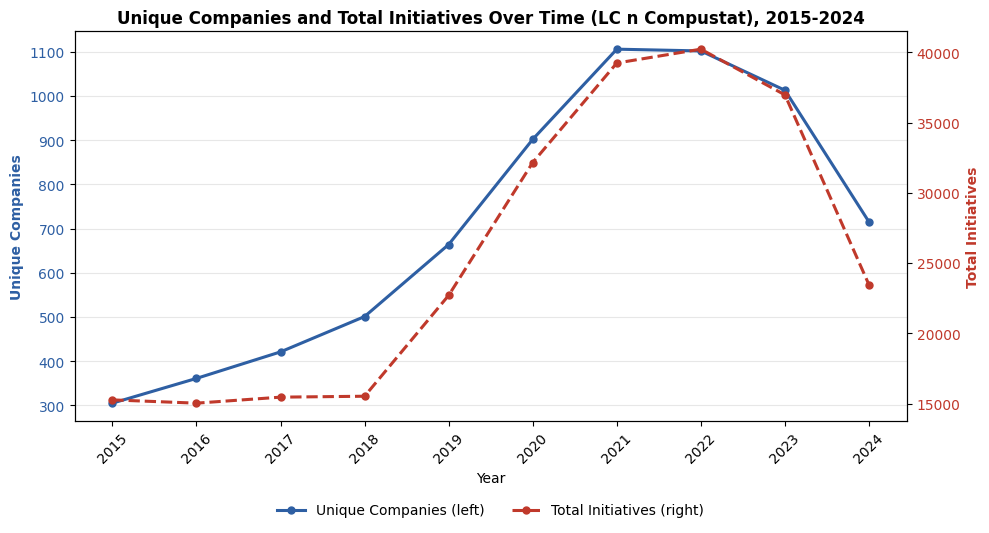

[plot] saved outputs/LC_USA_Compustat_Matched/fig2_signal_shares_over_time_matched.png
[data] saved outputs/LC_USA_Compustat_Matched/fig2_signal_shares_over_time_matched.xlsx


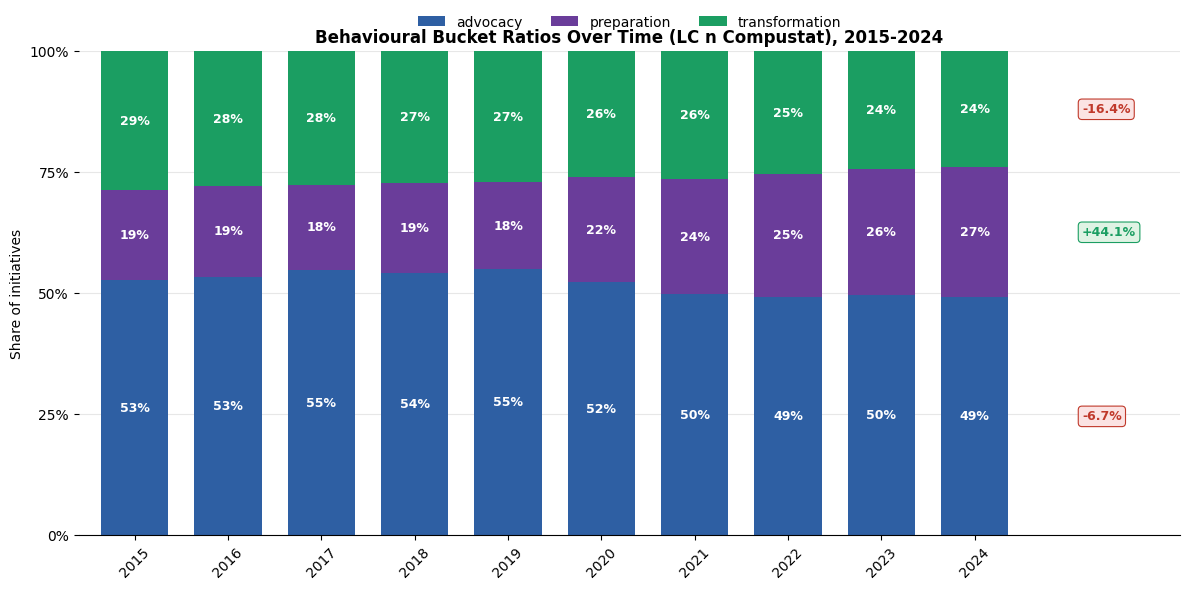

[plot] saved outputs/LC_USA_Compustat_Matched/fig3_signal_shares_by_sector_matched.png
[data] saved outputs/LC_USA_Compustat_Matched/fig3_signal_shares_by_sector_matched.xlsx


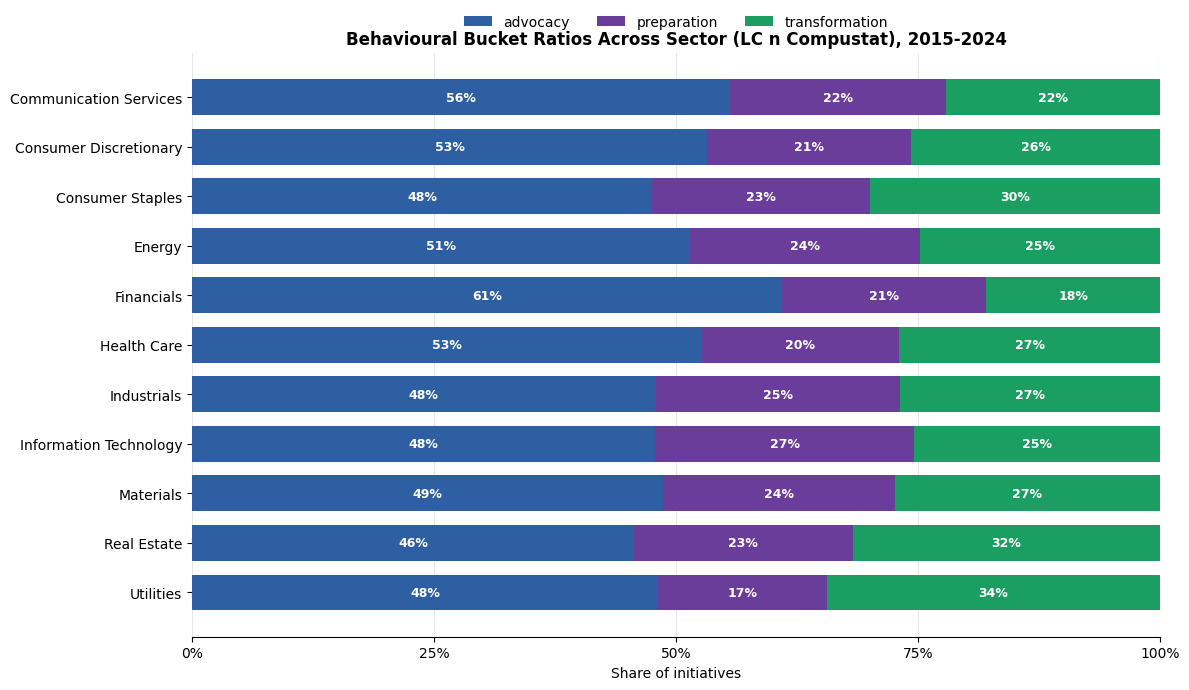

,unique_companies,firm_year_observations,total_initiatives
rfyear,,,
2015,305,305,15262
2016,361,361,15029
2017,421,421,15456
2018,501,501,15522
2019,664,664,22699
2020,902,902,32153
2021,1106,1106,39233
2022,1102,1102,40219
2023,1013,1013,36966


,advocacy,preparation,transformation
rfyear,,,
2015,52.7,18.6,28.6
2016,53.4,18.7,27.8
2017,54.8,17.7,27.5
2018,54.2,18.6,27.2
2019,55.0,17.9,27.0
2020,52.3,21.7,26.1
2021,49.8,23.9,26.3
2022,49.3,25.3,25.4
2023,49.7,26.0,24.3


,advocacy,preparation,transformation,n_obs
GICS_level_1,,,,
Utilities,48.2,17.4,34.4,437
Real Estate,45.6,22.6,31.8,660
Materials,48.6,23.9,27.4,580
Information Technology,47.8,26.8,25.4,519
Industrials,47.9,25.3,26.9,1282
Health Care,52.6,20.4,27.0,456
Financials,60.9,21.1,18.0,1253
Energy,51.4,23.8,24.8,446
Consumer Staples,47.5,22.5,30.0,446


In [11]:
# --- Same three plots, restricted to the LC <-> Compustat intersection ---
OUT_M = Path("outputs") / "LC_USA_Compustat_Matched"   # LC n Compustat sample
OUT_M.mkdir(parents=True, exist_ok=True)

fig1m, firms_initiatives_matched = plot_firms_and_initiatives(
    lc_merged,
    title=f"Unique Companies and Total Initiatives Over Time (LC n Compustat), {start_year}-{end_year}",
    save_path=OUT_M / "fig1_firms_and_initiatives_matched.png",
    excel_path=OUT_M / "fig1_firms_and_initiatives_matched.xlsx",
)

fig2m, shares_over_time_matched = plot_signal_shares_over_time(
    lc_merged, signal_names,
    title=f"Behavioural Bucket Ratios Over Time (LC n Compustat), {start_year}-{end_year}",
    save_path=OUT_M / "fig2_signal_shares_over_time_matched.png",
    excel_path=OUT_M / "fig2_signal_shares_over_time_matched.xlsx",
)

fig3m, shares_by_sector_matched = plot_signal_shares_by_sector(
    lc_merged, signal_names,
    sector_col="GICS_level_1",
    title=f"Behavioural Bucket Ratios Across Sector (LC n Compustat), {start_year}-{end_year}",
    save_path=OUT_M / "fig3_signal_shares_by_sector_matched.png",
    excel_path=OUT_M / "fig3_signal_shares_by_sector_matched.xlsx",
)

display(firms_initiatives_matched)
display(shares_over_time_matched.round(1))
display(shares_by_sector_matched.round(1))